In [144]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np
import plotly.express as px
sns.set(rc={'figure.figsize':(15,8), 'axes.titlesize': 20}, style="whitegrid")

# Датасет

### olist_customers_dataset.csv — таблица с уникальными идентификаторами пользователей
- `customer_id` — позаказный идентификатор пользователя
- `customer_unique_id` — уникальный идентификатор пользователя (аналог номера паспорта)
- `customer_zip_code_prefix` — почтовый индекс пользователя
- `customer_city` — город доставки пользователя
- `customer_state` — штат доставки пользователя

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')

In [3]:
customers.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


### olist_orders_dataset.csv —  таблица заказов
- `order_id` — уникальный идентификатор заказа (номер чека)
- `customer_id` — позаказный идентификатор пользователя
- `order_status` — статус заказа
- `order_purchase_timestamp` — время создания заказа
- `order_approved_at` — время подтверждения оплаты заказа
- `order_delivered_carrier_date` — время передачи заказа в логистическую службу
- `order_delivered_customer_date` — время доставки заказа
- `order_estimated_delivery_date` — обещанная дата доставки

#### Уникальные статусы заказов в таблице olist_orders_dataset:

- **created** — создан;
- **approved** — подтверждён;
- **invoiced** — выставлен счёт;
- **processing** — в процессе сборки заказа;
- **shipped** — отгружён со склада;
- **delivered** — доставлен пользователю;
- **unavailable** — заказ отменён по причине недоступности товара;;
- **canceled** — отменён.

In [4]:
orders = pd.read_csv('olist_orders_dataset.csv')

In [5]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


### olist_order_items_dataset.csv — товарные позиции, входящие в заказы
- `order_id` — уникальный идентификатор заказа (номер чека)
- `order_item_id` — идентификатор товара внутри одного заказа
- `product_id` — ид товара (аналог штрихкода)
- `seller_id` — ид производителя товара
- `shipping_limit_date` — максимальная дата доставки продавцом для передачи заказа партнеру по логистике
- `price` — цена за единицу товара
- `freight_value` — вес товара 

In [6]:
items = pd.read_csv('olist_order_items_dataset.csv')

In [7]:
items[items['order_id']=='00143d0f86d6fbd9f9b38ab440ac16f5']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.1
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.1
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.1


# Задачи

- **Задача 1**: Оценить месячный retention в оформление заказа с помощью когортного анализа.
- **Задача 2**: Определить, существует ли product/market fit у этого маркетплейса.
- **Задача 3**: Определить 5 основных метрик, на которых продакту можно сконцентрироваться, чтобы максимизировать прибыль компании.
- **Задача 4**: Выбрать одну из 3-х основных гипотез с помощью фреймворка ICE.
- **Задача 5**: Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.
- **Задача 6**: Подготовить отчет о проделанной работе. По задаче 6 возможная оценка: 0-12 баллов.

## Задача 0: EDA датасетов

In [8]:
# проверю на Nan-значения:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [9]:
orders.isna().sum() 
# в нескольких статусах есть пропущенные значения, что свидетельствует о том, что заказы не перешли в эти статусы и были отменены

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [11]:
customers.shape 

(99441, 5)

In [12]:
customers.customer_id.nunique() #количество уникальных ID позаказных покупателей

99441

In [13]:
customers.customer_unique_id.nunique() # а самих покупателей чуть меньше

96096

In [14]:
customers.customer_id.nunique()/customers.customer_unique_id.nunique() 
#получается, около одного заказа на человека, видимо очень мало повторных заказов. плохой знак.

1.0348089410589412

In [15]:
customers.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [16]:
customers.customer_id.unique() #формат ID позаказных клиентов

array(['06b8999e2fba1a1fbc88172c00ba8bc7',
       '18955e83d337fd6b2def6b18a428ac77',
       '4e7b3e00288586ebd08712fdd0374a03', ...,
       '5e28dfe12db7fb50a4b2f691faecea5e',
       '56b18e2166679b8a959d72dd06da27f9',
       '274fa6071e5e17fe303b9748641082c8'], dtype=object)

In [17]:
customers.customer_unique_id.unique() #формат ID клиентов

array(['861eff4711a542e4b93843c6dd7febb0',
       '290c77bc529b7ac935b93aa66c333dc3',
       '060e732b5b29e8181a18229c7b0b2b5e', ...,
       'e9f50caf99f032f0bf3c55141f019d99',
       '73c2643a0a458b49f58cea58833b192e',
       '84732c5050c01db9b23e19ba39899398'], dtype=object)

In [18]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-02-19 15:37:47,2018-02-27 04:31:10,2018-05-09 15:48:00,2016-10-27 17:32:07,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [19]:
# можно увидеть воронку статусов заказов, например долю доставленных заказов к созданным
96476/99441
# довольно высокий процент доставленных заказов!
# а вместе с информцией о почти отсутствующих повторных заказах можно предположить, что дело НЕ в сервисе доставки

0.9701833247855512

In [20]:
# чем торгуем?
items.describe(include='all')
# 32951 наименований товаров от 3095 производителей по цене от 6735 бразильских реалов (~100K рублей) до 0.85
# средняя цена товара 120 реалов (~1,796.99 рублей)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [101]:
items_per_orders = (
    items.groupby("order_id")
    .agg(items_count=('product_id','count')).sort_values('items_count', ascending = False)
)

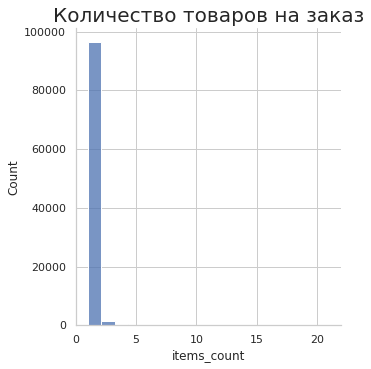

In [145]:
sns.displot(items_per_orders, x = 'items_count');
plt.title("Количество товаров на заказ")
plt.show()

In [23]:
items_per_orders.query('items_count != 1').count()/items_per_orders.count()
# доля заказов, содержащих больше 1 единицы товаров - 1%!

items_count    0.099355
dtype: float64

In [24]:
items_per_orders.query('items_count == 1')

,items_count
order_id,
a8b8b7289262a652bbc1c042766c97c8,1
ac9ec0af6e2e654e5b2b88f0ee326b4c,1
aa27bd1341335b1891bbcc4e1967b402,1
a8b89a642249efed782ce25e1798925c,1
a8ad75728836e5b2103463b917d0e6f4,1
...,...
5a07264682e0b8fbb3f166edbbffc6e8,1
5a071192a28951b76774e5a760c8c9b7,1
5a06fc966a12b41bf401b344464fd4b1,1


In [25]:
88863/items_per_orders.shape[0]

0.9006445989499929

In [26]:
items_per_orders.query('items_count != 1').count()*100/items_per_orders.count()
# доля заказов, содержащих больше 1 единицы товаров около 10%

items_count    9.93554
dtype: float64

In [27]:
orders_per_cust = customers.groupby("customer_unique_id").agg(cust_order = ("customer_id",'count'))

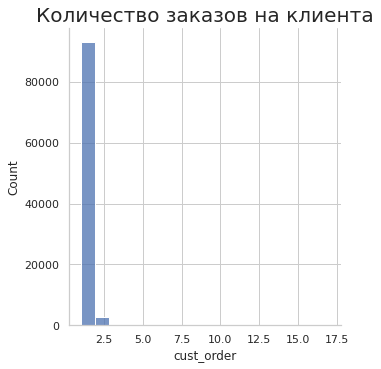

In [146]:
sns.displot(orders_per_cust, x = 'cust_order');
plt.title("Количество заказов на клиента")
plt.show()

In [29]:
orders_per_cust.query('cust_order != 1').count()*100/orders_per_cust.count()
# доля клиентов, совершивших больше одного заказа - примерно 3%. наверняка низкий будет ретеншн.

cust_order    3.118756
dtype: float64

In [30]:
# посмотрим среднюю стоимость доставленных заказов
price_mean = (
    items.merge(orders[["order_id", "customer_id", "order_status"]],on="order_id", how="inner")
    .query("order_status == 'delivered'")[["order_id", "price"]]
)
round(price_mean['price'].mean(),2)
    # средний чек совершенного и завершенного заказа 119.98 (по статусу заказов delivered)

119.98

In [31]:
items.groupby("order_id").agg({"price": "sum"}).mean() 
# средний чек заказа 137.75 (по всем статусам заказов, включая отмененные)

price    137.754076
dtype: float64

In [32]:
# что по географии?
customers['customer_city'].value_counts() 
# Сан-Паулу - лидер доставки, возможно тут штаб-квартира маркетплейса

sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
                         ...  
marques de souza             1
general maynard              1
cerrito                      1
mocajuba                     1
governador mangabeira        1
Name: customer_city, Length: 4119, dtype: int64

In [38]:
# хочу оценить объем отмененных заказов к общему числу
all_orders = orders.copy()
canceled_ratio = all_orders[all_orders["order_status"].isin(["canceled", "unavailable"])].order_id.nunique() / all_orders.order_id.nunique()
round(canceled_ratio*100,2)
# процент отмененных заказов чуть больше 1%, это интересно вкупе с тем фактом, что повторных заказов также мало.

1.24

In [40]:
# может быть, клиенты были недовольны скоростью доставки тогда? 
# оценю длительность доставки, и как соотносятся обещанный и фактический срок доставки 

orders_copy = orders.copy()
# привожу в датасете orders все даты к формату даты
orders_copy['order_purchase_timestamp'] = pd.to_datetime(orders_copy['order_purchase_timestamp'])
orders_copy['order_approved_at'] = pd.to_datetime(orders_copy['order_approved_at'])
orders_copy['order_delivered_carrier_date'] = pd.to_datetime(orders_copy['order_delivered_carrier_date'])
orders_copy['order_delivered_customer_date'] = pd.to_datetime(orders_copy['order_delivered_customer_date'])
orders_copy['order_estimated_delivery_date'] = pd.to_datetime(orders_copy['order_estimated_delivery_date'])

In [41]:
delivery_lag = orders_copy.copy() #будет датасет только для расчета доставки
delivery_lag.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [42]:
# создаю поле, вычисляющее длительность от создания заказа до его доставки
delivery_lag['create_del_fact'] = (
    delivery_lag['order_delivered_customer_date'] - delivery_lag['order_purchase_timestamp']).dt.days
lag_between_creat_delivered = (
    delivery_lag[["order_id","create_del_fact", "order_status"]].query("order_status == 'delivered'")
)
lag_between_creat_delivered = (
    lag_between_creat_delivered.dropna(subset=["create_del_fact"])
)

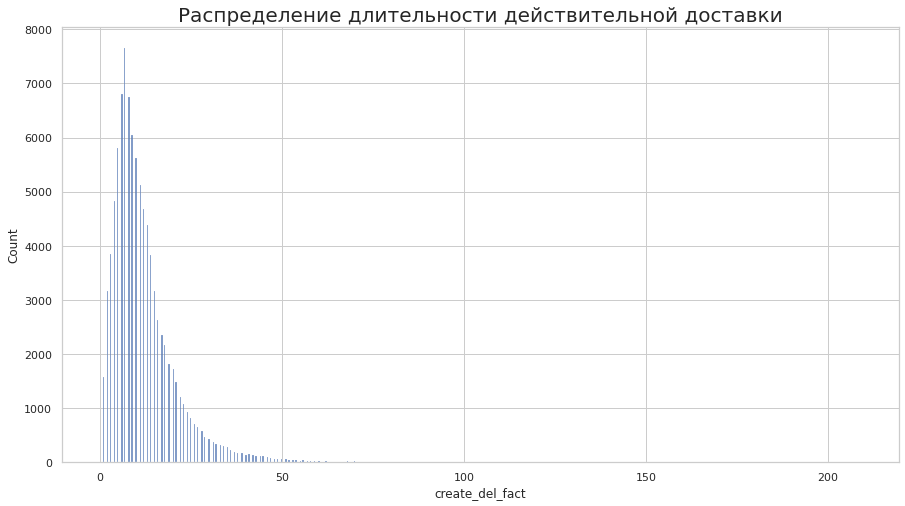

In [147]:
sns.histplot(lag_between_creat_delivered, x = "create_del_fact")
plt.title("Распределение длительности действительной доставки")
plt.show()

In [48]:
lag_between_creat_delivered['create_del_fact'].describe()
#среднее время от создания до доставки составлят 12 дней, 
# распредление с длинным правым хвостом за счет выброса в 209 дней
# 75 процентиль на уровне 15 дней

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: create_del_fact, dtype: float64

In [56]:
round(
(lag_between_creat_delivered['create_del_fact'] > lag_between_creat_delivered['create_del_fact'].mean()).sum() / lag_between_creat_delivered['create_del_fact'].notna().sum()
    ,2)
# и дольше 12 дней доставлялось 36% заказов

0.36

In [58]:
# а какие сроки доставки ожидались?
# создаю аналогичное поле времени от создания заказа до его предполагаемой доставки
delivery_lag['create_del_est'] = (
    delivery_lag.order_estimated_delivery_date - delivery_lag.order_purchase_timestamp).dt.days

lag_between_creat_estimated = (
    delivery_lag[["order_id","create_del_est", "order_status"]].query("order_status == 'delivered'")
)
lag_between_creat_estimated = lag_between_creat_estimated.dropna(subset=["create_del_est"])

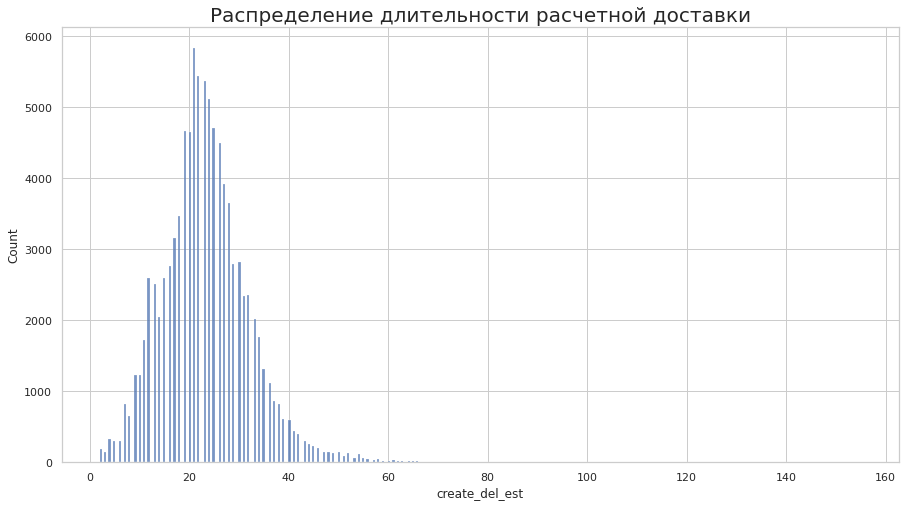

In [148]:
sns.histplot(lag_between_creat_estimated, x = "create_del_est")
plt.title("Распределение длительности расчетной доставки")
plt.show()

In [61]:
lag_between_creat_estimated['create_del_est'].describe()
# Ого, среднее расчетное время - 23 дня против 12 реального!
# не похоже, чтобы время доставки могло стать причиной отказа в последующих покупках

count    96478.000000
mean        23.372759
std          8.758137
min          2.000000
25%         18.000000
50%         23.000000
75%         28.000000
max        155.000000
Name: create_del_est, dtype: float64

## EDA: Выводы

### 1. География и концентрация спроса
Маркетплейс ориентирован преимущественно на внутренний рынок Бразилии, с высокой концентрацией активности в крупнейших городах — Сан-Паулу, Рио-де-Жанейро и Белу-Оризонти. 

### 2. Низкая повторяемость покупок
Подавляющее большинство клиентов совершают только одну покупку, а доля повторных заказов составляет около 3%. Это сигнал о слабом удержании и возможной проблеме с лояльностью. 

**Основная зона роста** — развитие retention-механик: персонализированные предложения, программы лояльности, коммуникации после первой покупки.

### 3. Средний чек
Средняя стоимость заказа около 120 реалов формирует понимание целевого ценового сегмента. 

При низкой частоте повторных покупок рост выручки может быть обеспечен либо увеличением LTV через удержание, либо ростом среднего чека (upsell, кросс-селл, комплекты товаров).

### 4. Логистика и клиентский опыт
Средний срок доставки — 12 дней при обещанных 25 днях. Это означает, что фактическая доставка происходит быстрее заявленного срока, что потенциально положительно влияет на удовлетворённость. Однако 35% заказов доставляются дольше среднего значения, что может создавать вариативность пользовательского опыта. 
**Возможна оптимизация SLA и более точное прогнозирование сроков.**

### 5. Низкий уровень возвратов
Доля возвратов (1,24%) находится на низком уровне. Это может свидетельствовать о корректном ожидании клиентов и приемлемом качестве товаров. Но также стоит проверить, не занижена ли эта метрика из-за барьеров в процессе возврата.

### 6. Структура заказов
В 90% заказов присутствует только одна товарная единица. Это указывает на слабую корзинную стратегию и потенциал роста через механики увеличения количества позиций в заказе (рекомендации, скидки при покупке нескольких товаров, бесплатная доставка от порога).

# Задача 1: Оценить месячный retention в оформление заказа с помощью когортного анализа.

### План 
1. Определить нужный датасет: Для когортного анализа нужен датасет активности покупателей. Активность по заказам представлена в датасете orders
2. Определить, какой вид заказа будет учитываться в retention
3. Добавить к этому датасету уникальные ID клиентов из датасета customers
4. Собрать таблицу для когортного анализа, рассчитать retention
5. Посчитать среднее значение retention за первый месяц
6. Найти когорту с самым высоким retention на 3-й месяц.
7. Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

In [63]:
# работаю только с доставленными заказами
orders_copy = orders_copy[orders_copy["order_status"] == "delivered"] 

In [64]:
# сохраню также датафрейм df1 для расчета когорт с тремя полями
df1 = orders_copy[["customer_id", "order_id","order_purchase_timestamp"]]

In [65]:
# к заказам добаляю уникальный ID клиентов customer_unique_id, чтобы по ним определять когорты
df1 = df1.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="inner")

In [67]:
# создаю поля месяц и день заказа
df1['order_period'] = df1['order_purchase_timestamp'].dt.to_period('M')
df1['order_period_day'] = df1['order_purchase_timestamp'].dt.to_period('D')

In [69]:
# задаю когорты по дате первого заказа для каждого клиента (а он у многих первый и последний)
df1['cohort'] = df1.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
df1['cohort_day'] = df1.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [70]:
df1.head(5)

,customer_id,order_id,order_purchase_timestamp,customer_unique_id,order_period,order_period_day,cohort,cohort_day
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-10-02,2017-09,2017-09-04
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24,2018-07,2018-07-24
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08,2018-08,2018-08-08
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11-18,2017-11,2017-11-18
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02-13,2018-02,2018-02-13


In [71]:
# вычисляю поле номера периода в днях, будем считать, что в месяце 30 дней
df1['period_number_month'] = np.floor((df1.order_period_day - df1.cohort_day).apply(attrgetter('n')) / 30)

In [72]:
df1.head(3)

,customer_id,order_id,order_purchase_timestamp,customer_unique_id,order_period,order_period_day,cohort,cohort_day,period_number_month
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-10-02,2017-09,2017-09-04,0.0
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24,2018-07,2018-07-24,0.0
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08,2018-08,2018-08-08,0.0


In [74]:
# собираю данные по когортам и номеру периода
cohort = (
    df1.groupby(['cohort', 'period_number_month'])
    .agg(n_customers=('customer_unique_id', 'nunique')).reset_index()
)

In [75]:
cohort

,cohort,period_number_month,n_customers
0,2016-09,0.0,1
1,2016-10,0.0,262
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1
...,...,...,...
210,2018-06,1.0,22
211,2018-06,2.0,6
212,2018-07,0.0,5949
213,2018-07,1.0,6


In [76]:
# таблицу cohort разворачиваю в сводную таблицу для когортного анализа
cohort_pivot = cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')
cohort_pivot
# невооруженным взглядом видно какой низкий ретенш с первого же месяца:
## тысячи пользователй в нулевой период и только десятки в первый

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1628.0,2.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,4.0,...,6.0,1.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN,NaN
2017-03,2503.0,7.0,13.0,11.0,3.0,2.0,9.0,4.0,6.0,6.0,...,4.0,4.0,3.0,7.0,2.0,3.0,2.0,NaN,NaN,NaN
2017-04,2256.0,8.0,6.0,1.0,6.0,8.0,6.0,10.0,5.0,6.0,...,3.0,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN
2017-05,3451.0,14.0,14.0,8.0,13.0,11.0,11.0,4.0,10.0,9.0,...,11.0,6.0,3.0,7.0,4.0,NaN,NaN,NaN,NaN,NaN
2017-06,3037.0,13.0,15.0,11.0,5.0,16.0,9.0,6.0,4.0,10.0,...,9.0,3.0,9.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
# расчитываю ретеншн
# размеры когорт -  нулевой период
cohort_size = cohort_pivot.iloc[:, 0]
# вычисляю коэффициенты ретеншн, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN
2017-03,1.0,0.002797,0.005194,0.004395,0.001199,0.000799,0.003596,0.001598,0.002397,0.002397,...,0.001598,0.001598,0.001199,0.002797,0.000799,0.001199,0.000799,NaN,NaN,NaN
2017-04,1.0,0.003546,0.002660,0.000443,0.002660,0.003546,0.002660,0.004433,0.002216,0.002660,...,0.001330,NaN,0.000887,0.000887,0.000887,0.000887,NaN,NaN,NaN,NaN
2017-05,1.0,0.004057,0.004057,0.002318,0.003767,0.003187,0.003187,0.001159,0.002898,0.002608,...,0.003187,0.001739,0.000869,0.002028,0.001159,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.004281,0.004939,0.003622,0.001646,0.005268,0.002963,0.001976,0.001317,0.003293,...,0.002963,0.000988,0.002963,0.001317,NaN,NaN,NaN,NaN,NaN,NaN


    ✅ Построить месячный retention

In [83]:
# сохраню как датафрейм нулевой столбец таблицы когорты - это новые покупатели
new_customers = cohort_pivot.iloc[:, 0:1] 
new_customers.mean()

# среднее количество покупателей - 4059

period_number_month
0.0    4059.043478
dtype: float64

In [87]:
# расчитываю медианный retention 1-го месяца 

average_retention_first_month = retention_matrix[1].median()
round(average_retention_first_month, 4)


0.0035

    ✅ Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)

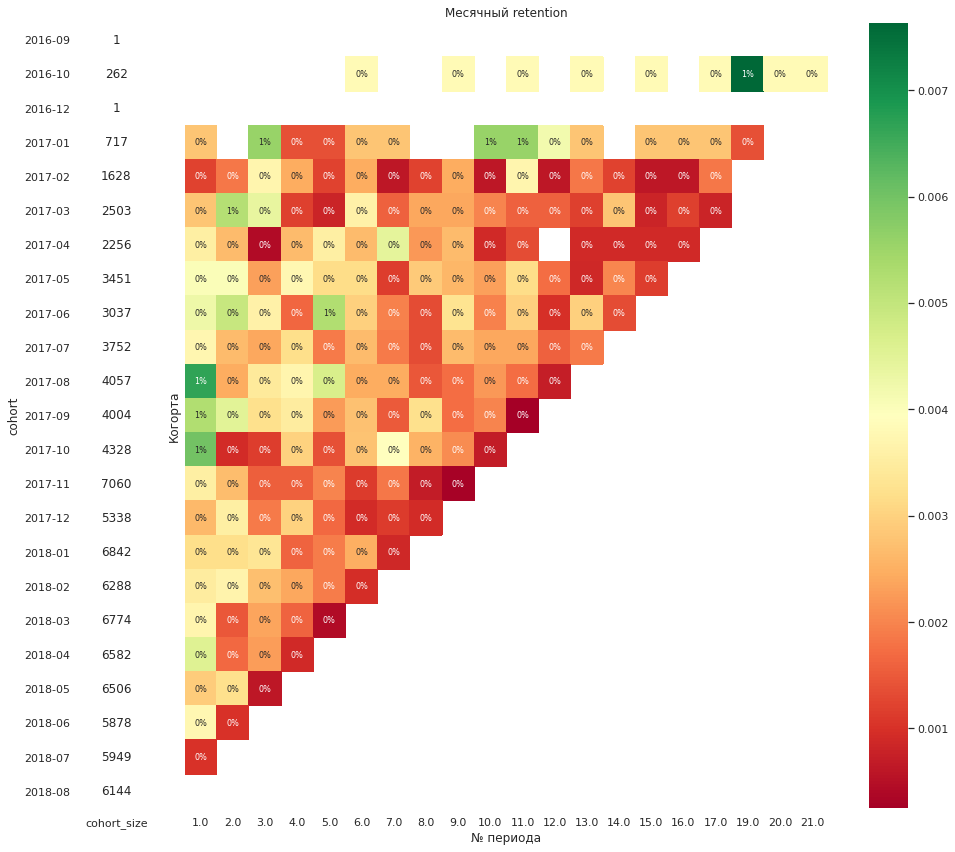

In [150]:
# построю тепловую карту когортного анализа 
## уберу нулевой месяц, чтобы остальные показатели ретеншн прокрасились более информативно
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(14, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})
    # Тепловая карта для коэффициентов ретеншн
    sns.heatmap(retention_matrix.iloc[:, 1:],
                mask=retention_matrix.iloc[:, 1:].isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                annot_kws={"size": 8},
                ax=ax[1])
    ax[1].set_title('Месячный retention', fontsize=12)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.savefig("monthly_retention.png", dpi=300, bbox_inches='tight')
    plt.show()

In [99]:
# Найти когорту с самым высоким retention на 3-й месяц
max_retention_third_month = retention_matrix[3].idxmax()
max_retention_value = retention_matrix[3].max()
round(max_retention_value,4)
# и по тепловой карте видно, что в 3м месяце самый высокий ретеншн в когорте 2017-01

0.0056

    ✅ Найти когорту с самым высоким retention на 3-й месяц: когорта 2017-01, ретеншн = 0.0056
    ✅ Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия ⬆️

## Задача 1. Выводы:

- Маркетплейс был запущен в сентябре 2016, но активный маркетингбыл запущен с января 2017, и в среднем  приводил ежемесячно 4059 новых клиента.
- Однако  все когорты демонстрируют резкое падение retention в первый же месяц, средний показатель retention 1го месяца 0.4%, лучший показатель retention первого месяца был в августе 2018 и равен 0.6655%
- Самый высокий retenton за 3й месяц был в январе 2017 и равен 0.5579%
- В большинстве когорт retention после 2-го месяца стремится к нулю, что говорит об отсутствии устойчивой пользовательской базы. Нет когорт с заметным ростом или стабильностью, все они затухают в течение 2–3 месяцев.
- Можно сделать предположение о низком product market fit

Чтобы быть уверенной в этом выводе, хорошо бы понимать товарную линейку данного маркетплейса, действительно ли предполагаемая частота покупок таких товаров - ежемесячная:

1. Могут ли это быть товары длительного пользования  (более двух лет, при среднем чеке 137.75 BRL - что это?), но возможно retention будет более показателен на более длинных периодах времени.
2. Если принять во внимание низкий процент возвратов (1.2%) и сроки доставки, почти вдвое ниже обещанного - тогда можно предположить, что неудовлетворенность качеством товаров и сервиса не должны быть причиной низких показателей месячного retention. С другой стороны, возможно издержки на возврат превышали ценность товара, поэтому клиенты не возвращали товары, но и не возрващались сами в маркетплейс.

# Задача 2: Определить, существует ли product/market fit у маркетплейса

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

_Для этого вам нужно:_

Определить, существует ли product/market fit у этого маркетплейса. Ведь до сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

_В рамках исследования необходимо:_

Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

## Задача 2. Выводы:
    На основании результатов когортного анализа можно предположить, что продукт пока не достиг устойчивого соответствия рынку (product/market fit выглядит слабым).

1. Приток новых пользователей
Матрица показывает, что ежемесячно в продукт приходит значимое число новых клиентов — медианное значение составляет около 4057 человек. Это говорит о том, что маркетплейс успешно привлекает аудиторию и вызывает первоначальный интерес. 
Однако сам по себе стабильный входящий поток пользователей ещё не означает, что бизнес развивается устойчиво в долгосрочной перспективе, что и показывает матрица удержания.

2. Слабое удержание
Несмотря на регулярное привлечение клиентов, показатели ретеншн крайне низкие. В первый месяц после первой покупки активными остаются лишь около 0,3% пользователей (по медиане), а уже ко второму месяцу удержание практически исчезает. Такая динамика указывает на то, что большинство клиентов не возвращаются после первого взаимодействия. 

Это может быть связано с несоответствием ожиданий клиентов от купленных товаров, недостаточной ценностью продукта (маркетплейса) или проблемами в пользовательском опыте (сложные возвраты? трудности с возвращением средств?).

3. Ценностное предложение требует пересмотра
Низкая повторная активность может означать, что продукт недостаточно выделяется на фоне конкурентов или не закрывает ключевые потребности аудитории. 
Причины могут лежать в области позиционирования, ассортимента, сервиса, удобства использования или общей конкурентоспособности предложения.

В совокупности текущие показатели удержания свидетельствуют о **слабом product/market fit**. Хотя маркетплейс способен стабильно привлекать новых клиентов, отсутствие возвратной активности подчёркивает необходимость пересмотра ценностного предложения, возможно работы с клиентским опытом - не хватает даных, чтобы это утвержать.

_Классическое "дырявое ведро"._

# Задача 3: Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

1. Первая метрика должна отражать рост объёма продаж маркетплейса.
2. Вторая — показывать объем аудитории, которой продукт доставляет ценность.
3. Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
4. Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
5. Пятая — отражать денежное выражение вовлеченности клиента.

Визуализируйте первую, вторую, четвёртую и пятую метрики. 
Используйте месячную гранулярность и окно в 1 месяц, если это нужно.


## 3.1. Метрика, отражающая рост объема продаж

Объем продаж **Gross Volume (GMV)**, показывает какой доход генерирует маркетплейс на некоторый период.

In [183]:
# беру датасет из расчета когорт, где только доставленные заказы и метками мемсяца "order_period"
gmv = df1.copy()

In [184]:
gmv = gmv.merge(items[['order_id', 'price']], on = "order_id") #добавляю информацию о стоимости
gmv

,customer_id,order_id,order_purchase_timestamp,customer_unique_id,order_period,order_period_day,cohort,cohort_day,period_number_month,price
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-10-02,2017-09,2017-09-04,0.0,29.99
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24,2018-07,2018-07-24,0.0,118.70
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08,2018-08,2018-08-08,0.0,159.90
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11-18,2017-11,2017-11-18,0.0,45.00
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02-13,2018-02,2018-02-13,0.0,19.90
...,...,...,...,...,...,...,...,...,...,...
110192,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,da62f9e57a76d978d02ab5362c509660,2018-02,2018-02-06,2018-02,2018-02-06,0.0,174.90
110193,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,737520a9aad80b3fbbdad19b66b37b30,2017-08,2017-08-27,2017-08,2017-08-27,0.0,205.99
110194,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,2018-01,2018-01-08,2018-01,2018-01-08,0.0,179.99
110195,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,2018-01,2018-01-08,2018-01,2018-01-08,0.0,179.99


In [185]:
months_gmv = gmv.groupby("order_period", as_index=False).agg(gmv=("price","sum")).sort_values(by = "order_period")
months_gmv

,order_period,gmv
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


In [186]:
months_gmv['order_period'] = months_gmv['order_period'].astype('str')

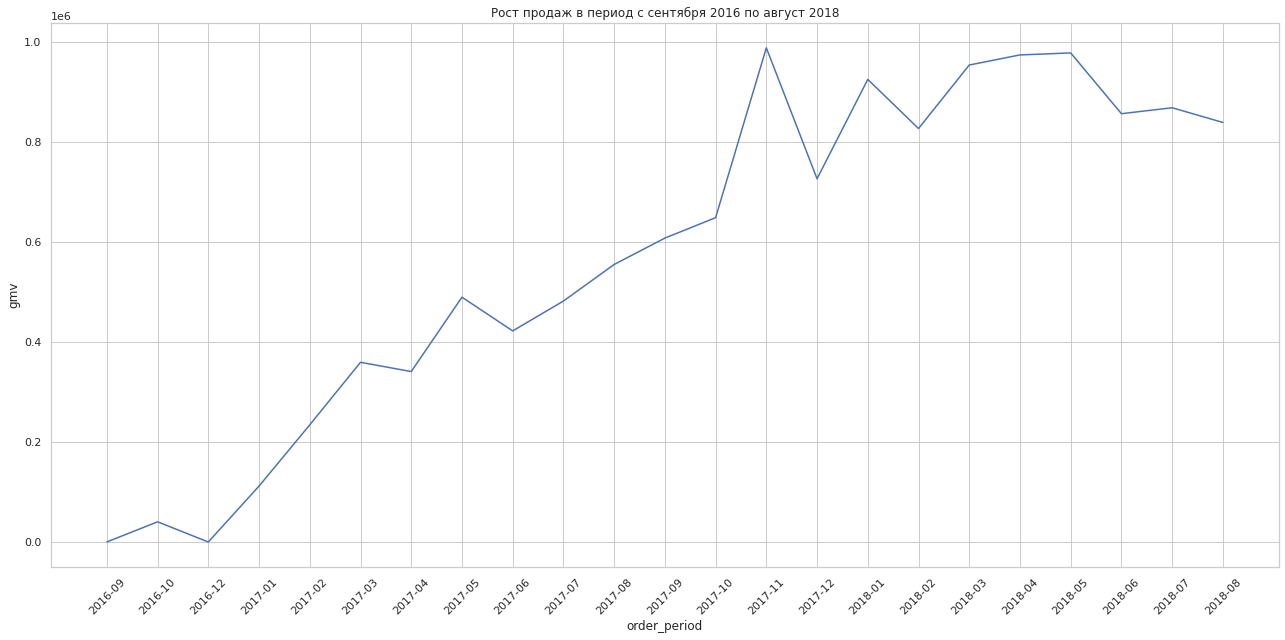

In [187]:
sns.lineplot(data=months_gmv, x = 'order_period', y= 'gmv')
plt.title("Рост продаж в период с сентября 2016 по август 2018")
plt.xticks(rotation=45)
plt.show;
#Рост, как помним, идет за счет привлечения новой аудитории

## 3.2. Метрика, показывающая объем аудитории, которой продукт доставляет ценность

Думаю, такой метрикой может быть объем платящей аудитории покупателей, то есть **Paying Users**

In [168]:
gmv.head()

,customer_id,order_id,order_purchase_timestamp,customer_unique_id,order_period,order_period_day,cohort,cohort_day,period_number_month,price
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2016-09,2017-10-02,2017-09,2017-09-04,0.0,29.99
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2016-10,2018-07-24,2018-07,2018-07-24,0.0,118.70
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2016-12,2018-08-08,2018-08,2018-08-08,0.0,159.90
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-01,2017-11-18,2017-11,2017-11-18,0.0,45.00
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2017-02,2018-02-13,2018-02,2018-02-13,0.0,19.90


In [188]:
paying_users = gmv.groupby("order_period", as_index = False ).agg(paying_users = ("customer_unique_id", "nunique"))
paying_users

,order_period,paying_users
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,718
4,2017-02,1630
5,2017-03,2508
6,2017-04,2274
7,2017-05,3479
8,2017-06,3076
9,2017-07,3802


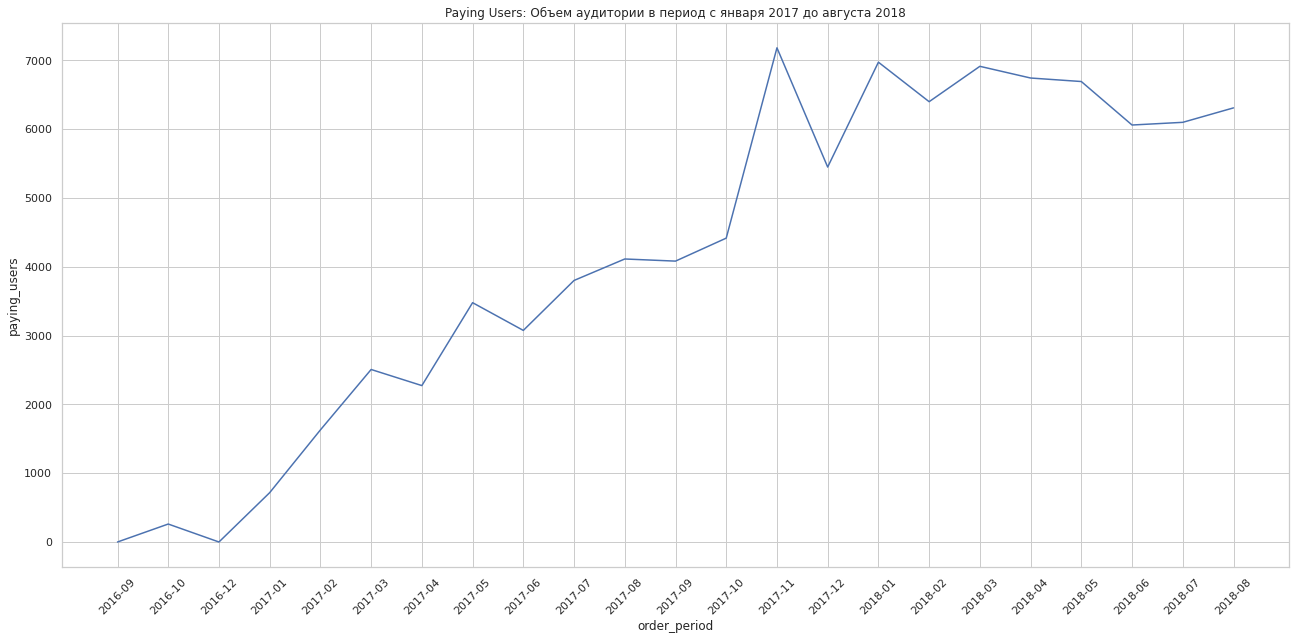

In [189]:
paying_users['order_period'] = paying_users['order_period'].astype('str')

sns.lineplot(data= paying_users, x= "order_period", y = "paying_users") 
plt.title("Paying Users: Объем аудитории в период с января 2017 до августа 2018")
plt.xticks(rotation=45)
plt.show();

Графики очень похожие, поскольку количество платяжих и объем выручки линейно зависимы

## 3.3. Метрика, отражающая заинтересованность новых клиентов в продукте 

_(даже если вы не можете посчитать ее на имеющихся у вас данных)_

Заинтересованность новых клиентов отражает **конверсия** из новых посетителей в покупателей.
В имеющихся данных нет информации о посетителях, есть данные сразу о покупателях.
Считается как доля совершивших первую покупку к числу новых посетителей

## 3.4. Метрика, отражающая вовлеченность клиента в продолжение использования продукта.

Это удержание, **Retention**, метрика показывающая долю клиентов, совершающие повторные покупки, а в общем случае продолжающие использовать продукт.
Можно посмотреть выше в martix_retention или на тепловой карте, вот еще раз она:

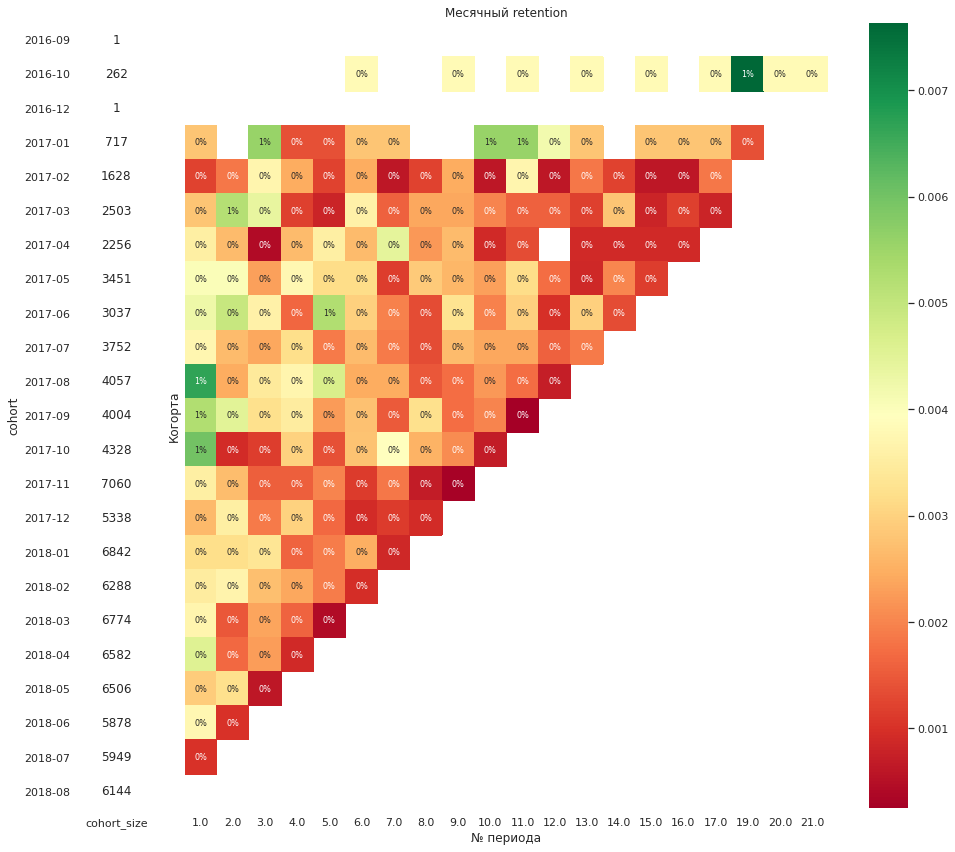

In [190]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(14, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})
    # Тепловая карта для коэффициентов ретеншн
    sns.heatmap(retention_matrix.iloc[:, 1:],
                mask=retention_matrix.iloc[:, 1:].isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                annot_kws={"size": 8},
                ax=ax[1])
    ax[1].set_title('Месячный retention', fontsize=12)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.savefig("monthly_retention.png", dpi=300, bbox_inches='tight')
    plt.show()

## 3.5. Метрика, отражающая денежное выражение вовлеченности клиента

Скорее всего, речь идет о средней выручке с платящего клиента, то есть ARPPU (Average Revenue Per Paying User)

In [193]:
arppu = (
    gmv.groupby("order_period", as_index = False).
    agg(total= ("price", "sum"), paying_users = ("customer_unique_id", "nunique"))
)

In [194]:
# добавляем колонку с расчетным средним доходом с платящих уникальных
arppu["arppu"] = arppu['total']/arppu['paying_users']

In [195]:
arppu

,order_period,total,paying_users,arppu
0,2016-09,134.97,1,134.970000
1,2016-10,40325.11,262,153.912634
2,2016-12,10.90,1,10.900000
3,2017-01,111798.36,718,155.708022
4,2017-02,234223.40,1630,143.695337
5,2017-03,359198.85,2508,143.221232
6,2017-04,340669.68,2274,149.810765
7,2017-05,489338.25,3479,140.654858
8,2017-06,421923.37,3076,137.166245
9,2017-07,481604.52,3802,126.671362


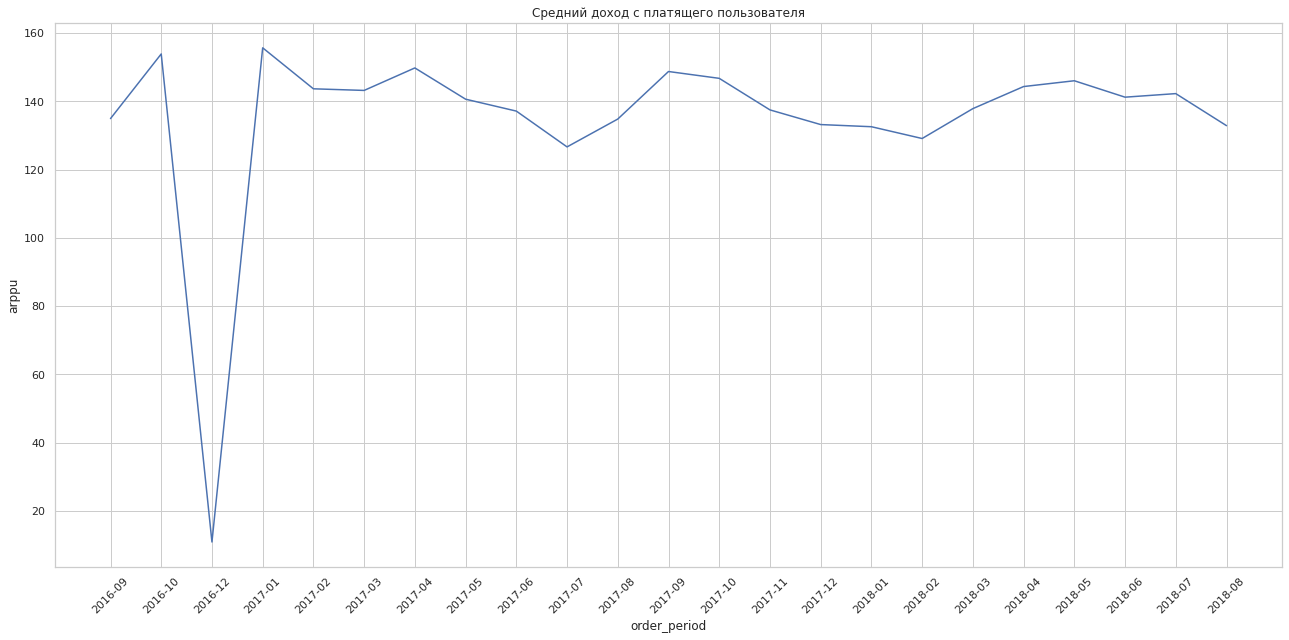

In [196]:
arppu['order_period'] = arppu['order_period'].astype('str')

sns.lineplot(data= arppu, x= "order_period", y = "arppu") 
plt.title("Средний доход с платящего пользователя")
plt.xticks(rotation=45)
plt.show();

# Задача 4


- Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

- **Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).**

### Гипотезы

1. Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен
2. Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.
3. Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [308]:
# подготовлю датасет для расчета Impact, данные с июня 2017 года.
orders_h1 = orders[["order_id","customer_id", "order_status", "order_purchase_timestamp", "order_delivered_customer_date","order_estimated_delivery_date"]].copy()
orders_h1.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [309]:
orders_h1["order_purchase_timestamp"] = pd.to_datetime(orders_h1["order_purchase_timestamp"])
orders_h1["order_delivered_customer_date"] = pd.to_datetime(orders_h1["order_delivered_customer_date"])
orders_h1["order_estimated_delivery_date"] = pd.to_datetime(orders_h1["order_estimated_delivery_date"])
orders_h1['order_month'] = orders_h1['order_purchase_timestamp'].dt.to_period('M')

In [310]:
orders_h1 = orders_h1[orders_h1["order_month"] >= '2017-06']
orders_h1

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2018-02
...,...,...,...,...,...,...,...
99433,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-20 20:25:45,2017-11-07,2017-10
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02,2018-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27,2017-08
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,2018-01


## 4.1 Гипотеза 1

        Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен

In [311]:
orders_h1.groupby("order_status").order_id.nunique()

order_status
canceled         499
created            5
delivered      85413
invoiced         240
processing       202
shipped          912
unavailable      475
Name: order_id, dtype: int64

In [312]:
# количество отмененных заказов  - это заказы в статусах canceled и unavailable
canceled_orders = orders_h1[(orders_h1.order_status.isin(['canceled', 'unavailable']))].order_id.nunique()
canceled_orders
# количество клиентов, на которых потенциально может повлиять это улучшение - 974 человека. 
## по таблице это 5 уровень Impact

974

In [313]:
Impact1 = 5 # согласно таблице

## 4.2 Гипотеза 2

        Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

Предвосхищая расчет, помню, что даты доставки фактические - меньше расчетных. 
Так что гипотеза до расчета не выглялит перспективной.

In [314]:
orders_h1['order_deliv_day'] = orders_h1['order_delivered_customer_date'].dt.to_period('D')
orders_h1['order_est_day'] = orders_h1['order_estimated_delivery_date'].dt.to_period('D')

In [315]:
orders_h1[['order_deliv_day','order_est_day']]

,order_deliv_day,order_est_day
0,2017-10-10,2017-10-18
1,2018-08-07,2018-08-13
2,2018-08-17,2018-09-04
3,2017-12-02,2017-12-15
4,2018-02-16,2018-02-26
...,...,...
99433,2017-10-20,2017-11-07
99437,2018-02-28,2018-03-02
99438,2017-09-21,2017-09-27
99439,2018-01-25,2018-02-15


In [316]:
lag_D_E = orders_h1[orders_h1["order_deliv_day"] > orders_h1["order_est_day"]].order_id.nunique()
lag_D_E #это количество заказов, которые были доставлены позднее обещанного

6088

In [317]:
# тогда принимая за значение конверсии медианный ретенш 1 месяца 0.0035, 
## рассчитываем потенциальное количество повторных заказов из этой выборки

0.0035*6088

# 21 заказ - возможное количество повторных заказов от тех клиентов, 
## что могли остаться недовольными задержкой доставки первого заказа

21.308

In [318]:
Impact2 = 1 # согласно таблице

## 4.3 Гипотеза 3

        Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

_Что же это за способ такой оплаты, который всех вернет?
И если при первом заказе клиенты справились со старым способом оплаты, почему вдруг новый решит проблему ретеншн.
Не знаю, г-н продакт, маловато уверенности._

In [322]:
# посчитаю количество клиентов, совершивших 1 заказ. Как помню, их большинство.
all_orders = (
    orders_h1[orders_h1["order_status"] == "delivered"]
    .merge(customers[["customer_unique_id", "customer_id"]], on="customer_id")
    .groupby('customer_unique_id')
    .agg(order_count=("order_id", "nunique"))
)
all_orders.query("order_count == 1").count() # количество клиентов с единственным заказом

order_count    80558
dtype: int64

In [323]:
round(0.0035*all_orders.query("order_count == 1").count(), 2)
# количество клиентов с повторным заказом, если гипотеза 3 верна

order_count    281.95
dtype: float64

In [324]:
Impact3 = 3 #согласно все той же таблице, значение метрики в диапазоне [151,350]

## 4.4 Задача 4. Выводы:

In [326]:
print(f"Значение Impact для гипотезы 1: {Impact1}, ICE: {8*6*Impact1}")
print(f"Значение Impact для гипотезы 2: {Impact2}, ICE: {10*4*Impact2}")
print(f"Значение Impact для гипотезы 3: {Impact3}, ICE: {5*9*Impact3}")

Значение Impact для гипотезы 1: 5, ICE: 240
Значение Impact для гипотезы 2: 1, ICE: 40
Значение Impact для гипотезы 3: 3, ICE: 135


    Гипотеза 1 имеет наивысший приоритет по ICE-модели

# Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять

1. Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
2. Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.

Выбранная гипотеза:

        Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен

## Целевые метрики
- Количество доставленных заказов.

Во-первых, сама гипотеза указывает на метрику "вследствие чего количество доставленных заказов увеличится".
Задача проверить, увеличится ли количество заказов после исправления бага в системе процессинга.

## Прокси метрики

- Доля доставленных заказов к общему количеству заказов,
Если изменение, заложенное в гипотезу, действительно сокращает количество отмен заказов, эта метрика также должна подрасти.

## Guardrail метрики
- Конверсия в оформление заказа - важно эту метрику не уронить вследствие врнесенных изменений
- Объем обращений в поддержку - если баг исправлен, то доля обращений должна сокращаться, но возможно увеличится объем обращений, связанных с последующими статусами заказов
- Доля возвратов заказов - очень интересно проследить как вообще эта метрика будет меняться